# 00. 추천 데이터 기초 EDA

GitHub Archive 집계 데이터를 추천 시스템 관점에서 탐색합니다.

- 데이터 기본 정보 (shape, dtype, NA)
- Event Type 분포
- User(actor) 활동량 분포
- Repo 활동량 분포
- User-Repo 상호작용 sparsity

## 1. 데이터 로드

In [1]:
from pathlib import Path

import pandas as pd

from gharchive.transform import optimize_types

DATA_DIR = Path("../../data/daily_agg")

df = pd.read_parquet(DATA_DIR)
df = optimize_types(df)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNA counts:\n{df.isna().sum()}")
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
df.head(10)

Shape: (38820324, 4)
Columns: ['actor_id', 'repo_id', 'type', 'cnt']

Dtypes:
actor_id       Int32
repo_id        Int32
type        category
cnt            Int32
dtype: object

NA counts:
actor_id       0
repo_id     1980
type           0
cnt            0
dtype: int64

Memory: 592.4 MB


,actor_id,repo_id,type,cnt
0,4042431,1158722851,MemberEvent,1
1,11262696,1086530565,MemberEvent,1
2,18427593,1158477283,MemberEvent,1
3,26726669,1158806092,PublicEvent,1
4,26934735,1158708644,MemberEvent,1
5,35613825,1118440283,CommitCommentEvent,2
6,35613825,1158787353,CommitCommentEvent,72
7,35613825,1152307145,CommitCommentEvent,1
8,35613825,1154355729,CommitCommentEvent,17
9,45545234,1158808755,PublicEvent,1


In [2]:
print(f"Unique actors: {df['actor_id'].nunique():,}")
print(f"Unique repos:  {df['repo_id'].nunique():,}")
print(f"Event types:   {df['type'].nunique()}")
print(f"\ncnt 기초 통계:")
print(df["cnt"].describe())

Unique actors: 6,097,393


Unique repos:  10,369,896
Event types:   16

cnt 기초 통계:


count    38820324.0
mean       2.615199
std       25.683428
min             1.0
25%             1.0
50%             1.0
75%             2.0
max         44102.0
Name: cnt, dtype: Float64


## 2. Event Type 분포

어떤 이벤트가 얼마나 발생하는가?

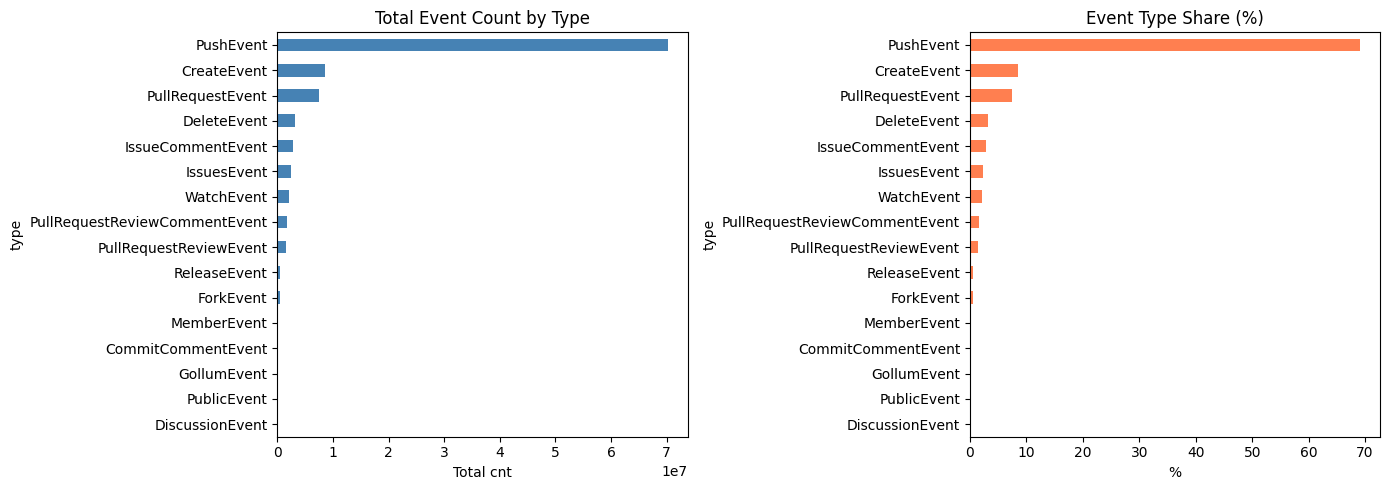


Event Type 비율:
  PushEvent                            69.2%
  CreateEvent                           8.4%
  PullRequestEvent                      7.4%
  DeleteEvent                           3.2%
  IssueCommentEvent                     2.8%
  IssuesEvent                           2.4%
  WatchEvent                            2.1%
  PullRequestReviewCommentEvent         1.6%
  PullRequestReviewEvent                1.5%
  ReleaseEvent                          0.5%
  ForkEvent                             0.5%
  MemberEvent                           0.2%
  CommitCommentEvent                    0.1%
  GollumEvent                           0.0%
  PublicEvent                           0.0%
  DiscussionEvent                       0.0%


In [3]:
import matplotlib.pyplot as plt

# 이벤트별 총 cnt 합산
type_counts = df.groupby("type", observed=True)["cnt"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 절대 수치
type_counts.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Total Event Count by Type")
axes[0].set_xlabel("Total cnt")
axes[0].invert_yaxis()

# 비율
type_pct = type_counts / type_counts.sum() * 100
type_pct.plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Event Type Share (%)")
axes[1].set_xlabel("%")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nEvent Type 비율:")
for t, pct in type_pct.items():
    print(f"  {t:35s} {pct:5.1f}%")

## 3. User(Actor) 활동량 분포

대부분의 유저는 소수의 이벤트만 발생시키고, 극소수가 대량의 이벤트를 발생시키는 **long-tail** 분포를 예상합니다.

Actor 수: 6,097,393

활동량 통계:
count      6097393.0
mean       16.650209
std      5715.122157
min              1.0
25%              1.0
50%              3.0
75%              8.0
max       13588843.0
Name: cnt, dtype: Float64

분위수:


  50.0%: 3
  75.0%: 8
  90.0%: 21
  95.0%: 39
  99.0%: 122
  99.9%: 593


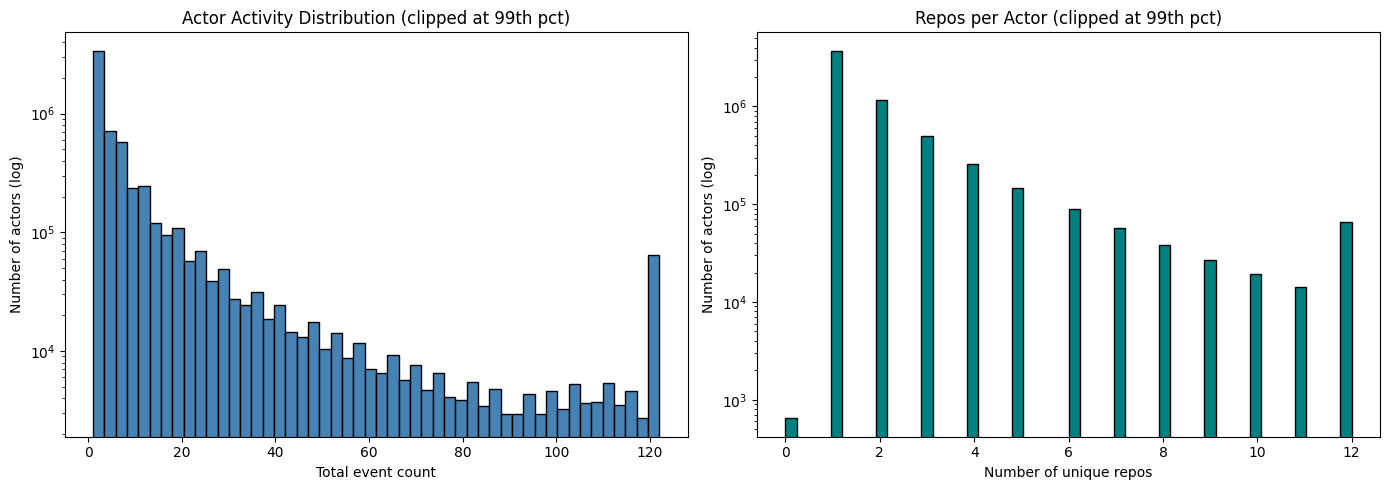

In [4]:
# 유저별 총 이벤트 수
actor_activity = df.groupby("actor_id")["cnt"].sum()

print(f"Actor 수: {len(actor_activity):,}")
print(f"\n활동량 통계:")
print(actor_activity.describe())

# 분위수 상세
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
print(f"\n분위수:")
for q in quantiles:
    print(f"  {q:5.1%}: {actor_activity.quantile(q):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 (log scale)
actor_activity.clip(upper=actor_activity.quantile(0.99)).plot.hist(
    ax=axes[0], bins=50, color="steelblue", edgecolor="black", log=True
)
axes[0].set_title("Actor Activity Distribution (clipped at 99th pct)")
axes[0].set_xlabel("Total event count")
axes[0].set_ylabel("Number of actors (log)")

# 유저별 상호작용한 repo 수
actor_repo_count = df.groupby("actor_id")["repo_id"].nunique()
actor_repo_count.clip(upper=actor_repo_count.quantile(0.99)).plot.hist(
    ax=axes[1], bins=50, color="teal", edgecolor="black", log=True
)
axes[1].set_title("Repos per Actor (clipped at 99th pct)")
axes[1].set_xlabel("Number of unique repos")
axes[1].set_ylabel("Number of actors (log)")

plt.tight_layout()
plt.show()

## 4. Repo 활동량 분포

Repo 수: 10,369,896

활동량 통계:


count    10369896.0
mean       9.789916
std      211.195487
min             1.0
25%             1.0
50%             2.0
75%             5.0
max        234937.0
Name: cnt, dtype: Float64

분위수:
  50.0%: 2


  75.0%: 5
  90.0%: 14
  95.0%: 28


  99.0%: 110
  99.9%: 531


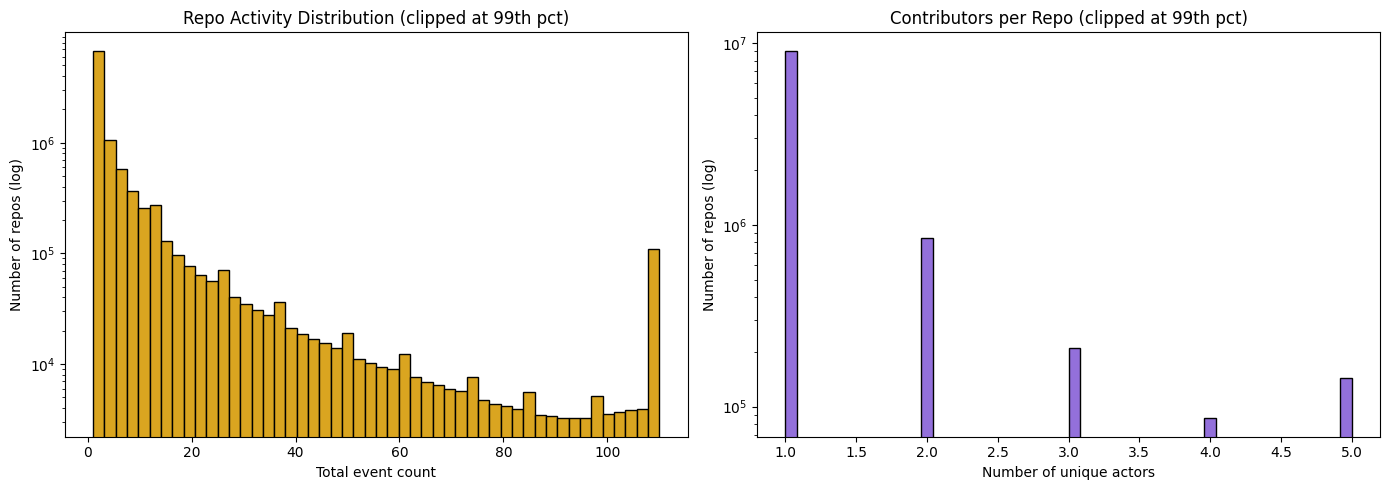

In [5]:
# repo별 총 이벤트 수
repo_activity = df.groupby("repo_id")["cnt"].sum()

print(f"Repo 수: {len(repo_activity):,}")
print(f"\n활동량 통계:")
print(repo_activity.describe())

print(f"\n분위수:")
for q in quantiles:
    print(f"  {q:5.1%}: {repo_activity.quantile(q):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# repo 이벤트 분포
repo_activity.clip(upper=repo_activity.quantile(0.99)).plot.hist(
    ax=axes[0], bins=50, color="goldenrod", edgecolor="black", log=True
)
axes[0].set_title("Repo Activity Distribution (clipped at 99th pct)")
axes[0].set_xlabel("Total event count")
axes[0].set_ylabel("Number of repos (log)")

# repo별 기여자(actor) 수
repo_actor_count = df.groupby("repo_id")["actor_id"].nunique()
repo_actor_count.clip(upper=repo_actor_count.quantile(0.99)).plot.hist(
    ax=axes[1], bins=50, color="mediumpurple", edgecolor="black", log=True
)
axes[1].set_title("Contributors per Repo (clipped at 99th pct)")
axes[1].set_xlabel("Number of unique actors")
axes[1].set_ylabel("Number of repos (log)")

plt.tight_layout()
plt.show()

## 5. User-Repo 상호작용 Sparsity

추천 시스템에서 가장 중요한 특성 중 하나.  
전체 가능한 (user, repo) 조합 대비 실제 관측된 비율이 얼마인가?

In [6]:
n_actors = df["actor_id"].nunique()
n_repos = df["repo_id"].nunique()
n_interactions = df.groupby(["actor_id", "repo_id"]).ngroups  # unique (actor, repo) pairs
total_possible = n_actors * n_repos
sparsity = 1 - (n_interactions / total_possible)

print(f"Unique actors:       {n_actors:>12,}")
print(f"Unique repos:        {n_repos:>12,}")
print(f"Possible pairs:      {total_possible:>12,}")
print(f"Observed pairs:      {n_interactions:>12,}")
print(f"Density:             {n_interactions / total_possible:>12.6%}")
print(f"Sparsity:            {sparsity:>12.6%}")

Unique actors:          6,097,393
Unique repos:          10,369,896
Possible pairs:      63,229,331,281,128
Observed pairs:        14,453,986
Density:                0.000023%
Sparsity:              99.999977%


## 6. Power User & Power Repo

상위 1% 유저/repo가 전체 이벤트의 몇 %를 차지하는가?

In [7]:
total_events = df["cnt"].sum()

for entity, activity in [("Actor", actor_activity), ("Repo", repo_activity)]:
    top_1pct_threshold = activity.quantile(0.99)
    top_1pct_sum = activity[activity >= top_1pct_threshold].sum()
    top_1pct_share = top_1pct_sum / total_events * 100

    top_10pct_threshold = activity.quantile(0.90)
    top_10pct_sum = activity[activity >= top_10pct_threshold].sum()
    top_10pct_share = top_10pct_sum / total_events * 100

    print(f"[{entity}]")
    print(f"  Top  1% ({entity.lower()} cnt >= {top_1pct_threshold:,.0f}): 전체 이벤트의 {top_1pct_share:.1f}%")
    print(f"  Top 10% ({entity.lower()} cnt >= {top_10pct_threshold:,.0f}): 전체 이벤트의 {top_10pct_share:.1f}%")
    print()

[Actor]
  Top  1% (actor cnt >= 122): 전체 이벤트의 52.8%
  Top 10% (actor cnt >= 21): 전체 이벤트의 77.2%



[Repo]
  Top  1% (repo cnt >= 110): 전체 이벤트의 41.2%
  Top 10% (repo cnt >= 14): 전체 이벤트의 73.2%



## 7. 정리

- **데이터**: 28일간 약 3,900만 row, ~600만 유저, ~1,000만 repo
- **Event 분포**: PushEvent가 압도적, WatchEvent(Star)는 그 다음
- **Long-tail**: 대다수 유저/repo는 소수의 이벤트만 가짐 → power law
- **Sparsity**: 극도로 sparse한 상호작용 행렬 → collaborative filtering 적용 시 주의
- **Power user/repo**: 상위 1%가 전체 이벤트의 상당 부분 차지 → 필터링 또는 정규화 필요